## Richness -- redMaPPer vs Spec

Bin the spectroscopic richness by their RM_lambda bins and plot log-linear relations. 

Compare these relations with the slopes in the literature. 

Re-adjust the intercepts so that they share the same pivot. It's the slope not the intercept that matters. 

Compare the relations with Sunayama and Sebastian Bocquet. Compare the slopes only. 

In [1]:
from scipy.stats import kde
import h5py
import astropy.io.fits as fits
import csv
import pandas as pd
import numpy as np
import tables
import pickle
import os
from astropy.table import Table
from astropy.coordinates import SkyCoord
from tqdm import tqdm
from astropy.io import ascii
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import incredible as cr
from scipy.special import erf
from scipy import stats
import scipy.optimize as opt
from scipy import stats
import scipy.optimize as opt
import emcee
import tqdm
import pickle
from astropy import table
from astropy.table import Table, join, unique
from specutils import SpectralRegion
from scipy.interpolate import BSpline, make_interp_spline, UnivariateSpline

from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
import numpy as np
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18
from astropy.cosmology import z_at_value
cosmo = Planck18

## Functions for computing spectroscopic richness and profiles
from projection_functions import *


##Plotting
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt

plot_params = {

'axes.linewidth': 1.25,
'xtick.major.width': 1, 'ytick.major.width': 1,
'xtick.minor.width': 1, 'ytick.minor.width': 1,
'xtick.major.size': 12, 'ytick.major.size': 12,
'xtick.labelsize': 12, 'ytick.labelsize': 12,
'xtick.direction': 'in', 'ytick.direction': 'in',
'xtick.major.pad': 6, 'xtick.minor.pad': 6,
'figure.constrained_layout.use': True,
#'text.usetex': True,
'font.family': 'Serif',
'font.size': 14,
'legend.fontsize': 11
    
}
plt.rcParams.update(plot_params)

## Selecting the fitting method

Select the desired BCES method by setting the variable `bcesMethod`. The available methods are:

| Value  | Method  |  Description |
|---|---| --- |
| 0  | $y|x$  | Assumes $x$ as the independent variable |
| 1  |  $x|y$ | Assumes $y$ as the independent variable |
| 2  | bissector  | Line that bisects the $y|x$ and $x|y$. *Do not use this method*, cf. [Hogg, D. et al. 2010, arXiv:1008.4686](http://labs.adsabs.harvard.edu/adsabs/abs/2010arXiv1008.4686H/). |
| 3  | orthogonal  | Orthogonal least squares: line that minimizes orthogonal distances. Should be used when it is not clear which variable should be treated as the independent one |

As usual, please read the [original BCES paper](http://labs.adsabs.harvard.edu/adsabs/abs/1996ApJ...470..706A/) to understand what these different lines mean.

In [2]:
import bces.bces as BCES
from scipy.optimize import curve_fit
from scipy.stats.distributions import chi2

# Define your fitting function
def loglinear_function(x, m, c):
    return m * np.log10(x) + c

'''
Fitting using Bivariate Correlated Errors and Intrinsic Scatter (BCES). Need to take into account covariance!
'''
def linear_fit(x, y, xerr, yerr, verbose=False, bcesMethod=0):
    logx = np.log10(x)
    logy = np.log10(y)
    logxerr = xerr/(x*np.log(10))
    logyerr = yerr/(y*np.log(10))
    cov = np.zeros_like(lambda_rm_list)
    #cov = np.ones_like(lambda_rm_list)*np.cov(x,y)[1,0] # Covariance between xerr and yerr (set to zeros if uncorrelated)

    # Perform BCES regression
    a, b, aerr, berr, covab = BCES.bces(logx, logxerr, logy, logyerr, cov)
    
    # 'a' and 'b' contain the best-fit parameters (slope and intercept) for different BCES lines.
    # 'aerr' and 'berr' are their respective standard deviations.
    # 'covab' is the covariance between 'a' and 'b'.
    
    # For example, to access the OLS(Y|X) results (index 0):
    slope_ols_yx = a[bcesMethod]
    intercept_ols_yx = b[bcesMethod]
    slope_err_ols_yx = aerr[bcesMethod]
    intercept_err_ols_yx = berr[bcesMethod]
    covab = covab[bcesMethod]

    if verbose:
        print(f"OLS(Y|X) Slope: {slope_ols_yx:.2f} +/- {slope_err_ols_yx:.2f}")
        print(f"OLS(Y|X) Intercept: {intercept_ols_yx:.2f} +/- {intercept_err_ols_yx:.2f}")

    return  slope_ols_yx, intercept_ols_yx, slope_err_ols_yx, intercept_err_ols_yx, covab

'''
For correlated errors on x and y for linear fit. Double check if this is running correctly. 
'''
def compute_chisq(x, y, xerr, yerr, slope, intercept, cov=True, verbose=False):
    # Calculate the effective variance for each point with covariance
    logx = np.log10(x)
    logy = np.log10(y)
    logxerr = xerr/(x*np.log(10))
    logyerr = yerr/(y*np.log(10))
                                   
    df_dlogx_at_x = slope #Derivative at each x_data point 
    #df_dx_at_x = 10**intercept *(slope)*x**(slope-1)

    ##Not considering the covariance of x,y the effective variance is given by: https://www.roma1.infn.it/~dagos/lfit/node4.html
    if cov:
        effective_variance = (logyerr**2 + (df_dlogx_at_x * logxerr)**2) + np.ones_like(xerr)*2*np.cov(logx,logy)[1,0]
    else:
        effective_variance = (logyerr**2 + (df_dlogx_at_x * logxerr)**2)
    
    # Calculate the chi-squared statistic
    #y_fitted = np.log10(10**intercept * x**slope)
    logy_fitted = slope*logx + intercept
    chi_squared = np.sum((logy - logy_fitted)**2 /effective_variance)
    
    # Degrees of freedom (N - number of parameters)
    degrees_of_freedom = len(x) - 2
    p_value = chi2.sf(chi_squared, degrees_of_freedom)

    if verbose:
        print(f"Chi-squared statistic: {chi_squared:.3f}")
        print(f"Degrees of freedom: {degrees_of_freedom}")
        print(f"P-value using sf: {p_value}")
        print(f"Covariance is:  {np.cov(logx,logy)[1,0]}")
        print(f"Variance is: {(logyerr**2 + (df_dlogx_at_x * logxerr)**2)}")
    
    return chi_squared, degrees_of_freedom, p_value

## Importing Catalogs and applying cuts

In [3]:
with open('bgs_clus_RM_gal_matched.pickle', 'rb') as handle:
    bgs_matched = pickle.load(handle)

fcols = ['g','r','z','w1','w2']
for col in fcols:
    #bgs_matched['flux_'+col.lower()+'_dered'] = bgs_matched['FLUX_'+col]/data['MW_TRANSMISSION_'+col]
    bgs_matched['r_dered'] = 22.5 - 2.5*np.log10(bgs_matched['flux_r_dered'])
    bgs_matched['g_dered'] = 22.5 - 2.5*np.log10(bgs_matched['flux_g_dered'])
    bgs_matched['gmr'] = bgs_matched['g_dered']-bgs_matched['r_dered']

#binGap = 1e-5
wide_bin_1 = np.linspace(-0.1,-0.005,21, endpoint=False)
small_bin = np.linspace(-0.005,0.005,21, endpoint=False)
micro_bin = np.linspace(-0.005,0.005,31)
wide_bin_2 = np.linspace(0.005,0.1,21, endpoint=False)


binBoundaries = np.hstack((wide_bin_1, small_bin))
binBoundaries = np.hstack((binBoundaries, wide_bin_2))
binCent = np.asarray([(binBoundaries[i] + binBoundaries[i+1])/2 for i in range(len(binBoundaries)-1)])
binCent_micro = np.asarray([(micro_bin[i] + micro_bin[i+1])/2 for i in range(len(micro_bin)-1)])
bin_width = np.asarray([binBoundaries[i+1]-binBoundaries[i] for i in range(len(binBoundaries[:-1]))])

## None overlapping bins
assert len(set(binCent)) == len(binCent), "Overlapping bins"
assert len(set(binBoundaries)) == len(binBoundaries), "Overlapping bins"

## Binning 

In [4]:
## Bin by redshift
z_bins = [[0.1,0.2],[0.2,0.3],[0.3,0.4]]

lmda_bin_edges = np.logspace(np.log10(30), np.log10(120), 7)
lmda_bins = [[lmda_bin_edges[i], lmda_bin_edges[i+1]] for i in range(len(lmda_bin_edges)-1)]

##Create an absolute magnitude column
cosmo = Planck18
h = 0.67
M_r = bgs_matched['r_dered']-cosmo.distmod(bgs_matched['Z_BGS']).value - 5*np.log10(h)
bgs_matched['M_r'] = M_r ##comoving M with h-scaling

##Cuts
bgs_matched = bgs_matched[np.where(bgs_matched['r_dered'] < 19.5)]

## Individual Measurements

In [5]:
from astropy.stats import jackknife_stats as jk_stats
'''
Outputs total spec richness w/o continuum removal, spec richness after continuum removal for stacked.
'''
def calc_specRichness_stacked(binBoundaries, binCent, table):
    x, weights_all = calc_weights_all(binBoundaries, table)
    bin_width = np.asarray([binBoundaries[i+1]-binBoundaries[i] for i in range(len(binBoundaries[:-1]))])
    y_continuum_prob = calc_Continuum(binBoundaries, binCent, table)
    continuum_prob_spl = UnivariateSpline(binCent, y_continuum_prob, s=0)
    pdf, y_err = calc_zDiff(binBoundaries, table, numCount_bool=False)
    totNum = len(table)
    numCluster = len(np.unique(table['ID']))
    
    if np.any(np.isnan(pdf)): 
        raise ValueError("Input value cannot be NaN.")

    lambda_true = np.sum((pdf-continuum_prob_spl(binCent))*bin_width*weights_all)*totNum/numCluster 
    lambda_tot = np.sum(pdf*bin_width*weights_all) * totNum/numCluster 

    ##Rerun with jackknife error
    y_err_weighted = y_err*bin_width*weights_all*totNum/numCluster
    
    lambda_err_std = np.sqrt(np.sum(y_err_weighted)) ##Check if this is correct. 
    #lambda_err_jk, bias, stderr, conf_interval= jk_stats(y_err_weighted, np.std, confidence_level = 0.68)
    return lambda_tot, lambda_true, lambda_err

In [6]:
#Assigning spectrospic richnesses to individual cluster. 

from scipy.stats import gaussian_kde
import matplotlib.colors as colors

rmTable = unique(bgs_matched, keys='ID')
ID_list, lambda_tot_list, lambda_true_list  = calc_specRichness_individual(binBoundaries, binCent, bgs_matched)
lambda_rm = [rm_lambda for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
rm_id = [rmTable['ID'][i] for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
ind = [i for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list]

lambda_tot_list = np.asarray(lambda_tot_list)
lambda_true_list = np.asarray(lambda_true_list)
lambda_rm = np.asarray(lambda_rm)

##Filtering out the clusters with no spectrospic richness information and assigning spectroscopic information
rmTable = rmTable[ind]
rmTable['lambda_true'] = lambda_true_list
rmTable['lambda_tot'] = lambda_tot_list
rm_df = rmTable.to_pandas()

## Group df by lmba_bins
# Create a binned column
rm_df['lmda_bin'] = pd.cut(rm_df['LAMBDA'], lmda_bin_edges)

/global/homes/z/zzhang13/.conda/envs/myEnv_v39/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/global/homes/z/zzhang13/.conda/envs/myEnv_v39/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


In [7]:
from astropy.stats import jackknife_stats as jk_stats

for i, lmda_bin in enumerate(lmda_bins):
   cut = (rm_df['LAMBDA'] >= lmda_bin[0]) & (rm_df['LAMBDA'] < lmda_bin[1])      
   curTable = bgs_matched[cut]
      
   ##Individual 
   lambda_true_err_jk, bias, std_err, _ = jk_stats(curTable['lambda_true'], np.std, confidence_level=0.68)
   print(np.mean(curTable['lambda_tot']), np.mean(curTable['lambda_true']), lambda_true_err_jk)
   
   ##stacked analysis
   lambda_tot_stacked, lambda_true_stacked, lambda_true_err = calc_specRichness_stacked(binBoundaries, binCent, curTable)
   print(lambda_tot_stacked, lambda_true_stacked, lambda_true_err)


ValueError: Illegal type <class 'pandas.core.series.Series'> for table item access

## Binned Measurements

* All
* Binned by luminosity
* Redshift
* Outlier removal (sigma-clipping)
* Confidence bands.
* Plot scatter plot compare with Gaussian. 

In [ ]:
### Plotting params
smoothing_param = 0
xlim_inset_low = -0.005; xlim_inset_high = 0.005
xlim_low = -0.1; xlim_high = 0.1
ylim_low = 1; ylim_high = 1e4
ylim_inset_low = 10; ylim_inset_high = 1e4
z_anchor = 0.4
shift_wide_val = 0.0002
shift_small_val = 0.0001
fontsize=14
alpha=0.5

## Apply simultaneuous absolute magnitude and redshit cuts
| Redshift| Magnitude |
|-----|-----|
| $z\in[0.1,0.33)$ | -20.99|
| $z\in[0.33,0.4)$ | -21.5 |

In [ ]:
MagDict = {
           #r'$ M_r < -19.8$': np.asarray((bgs_matched['M_r'] <-19.8)), \
           r'$ M_r < -20.99, $': np.asarray((bgs_matched['M_r'] <-20.99)), \
           r'$ M_r < -21.5, $': np.asarray((bgs_matched['M_r'] <-21.5)), 
          }

zDict = {
           r'$z \in [0.10,0.33)$':np.asarray((bgs_matched['Z_SPEC_x'] >= 0.10) & (bgs_matched['Z_SPEC_x'] < 0.33)), \
           #r'$z \in [0.20,0.30)$':np.asarray((bgs_matched['Z_SPEC_x'] >= 0.20) & (bgs_matched['Z_SPEC_x'] < 0.30)), \
           r'$z \in [0.33,0.40)$':np.asarray((bgs_matched['Z_SPEC_x'] >= 0.33) & (bgs_matched['Z_SPEC_x'] < 0.40))
          }

#fmtList = ['h', 'o', 'D', '*']
#MagDict = [ {k1:MagDict[k1], 'fmt':k2} for k1, k2 in zip(MagDict, fmtList)]

In [ ]:
##Valid indices -- see table
validInd = [[0,0],[1,1]]

combinedDict = {}
for i, (key1, val1) in enumerate(MagDict.items()):
    for j, (key2, val2) in enumerate(zDict.items()):
        if any([i,j] == sublist for sublist in validInd):
            name = key1 + ' ' + key2
            val = val1 & val2 ##Boolean logic
            combinedDict[name] = val

        else:
            continue

## Plotting trends

Todo items:
1. Check fit with and without errors on x and y
2. Plot confidence bands.

Caveats:
Bootstrap method does not work. 

### Plotting with y errors only

We set the pivot point to $\lambda_{RM}$ of 60. To do so we change the intercept. Note that in doing so the values change and so do the errors. 

In [ ]:
for key, val in combinedDict.items():
    print(key)
    cutTable = bgs_matched[val]
    numTotal = len(cutTable)
    numCluster = len(np.unique(cutTable['ID']))

    lambda_true_list = []
    lambda_rm_list = []
    lambda_rm_stddev_list = []
    lambda_true_stddev_list = []
    lambda_rm_sem_list = []
    lambda_true_sem_list = []
    for i, lmda_bin in enumerate(lmda_bins):
        cut = (cutTable['LAMBDA'] >= lmda_bin[0]) & (cutTable['LAMBDA'] < lmda_bin[1])
            
        binnedTable = cutTable[cut]
        lambda_tot, lambda_true, lambda_true_err = calc_specRichness_stacked(binBoundaries, binCent, binnedTable)
        print(lambda_true_err_std, lambda_true_err)
        

        numCl = len(unique(binnedTable, keys='ID'))
        lambda_rm_list = np.hstack((lambda_rm_list, np.mean(binnedTable['LAMBDA'])))  
        lambda_rm_stddev_list = np.hstack((lambda_rm_stddev_list, np.std(binnedTable['LAMBDA']))) 
        lambda_rm_sem_list = np.hstack((lambda_rm_sem_list, stats.sem(binnedTable['LAMBDA'])))  
        lambda_true_stddev_list = np.hstack((lambda_true_stddev_list, lambda_true_err))
        lambda_true_sem_list = np.hstack((lambda_true_sem_list, lambda_true_err/np.sqrt(numCl)))
        lambda_true_list = np.hstack((lambda_true_list,lambda_true))   

    ##Linear fitting
    bcesMethod=0
    ##Use the standard error for errors on the coefficients. 
    slope, intercept, slope_err, intercept_err, covab = linear_fit(lambda_rm_list, lambda_true_list, lambda_rm_sem_list, lambda_true_sem_list, bcesMethod=bcesMethod)

    ##Use the standard error of the regression (approx. standard deviation) for goodness of fit.
    chi_squared, degrees_of_freedom, p_value = compute_chisq(lambda_rm_list, lambda_true_list, lambda_rm_stddev_list, lambda_true_stddev_list, slope, intercept, \
                                                             cov=False, verbose=True)
    

NameError: name 'combinedDict' is not defined

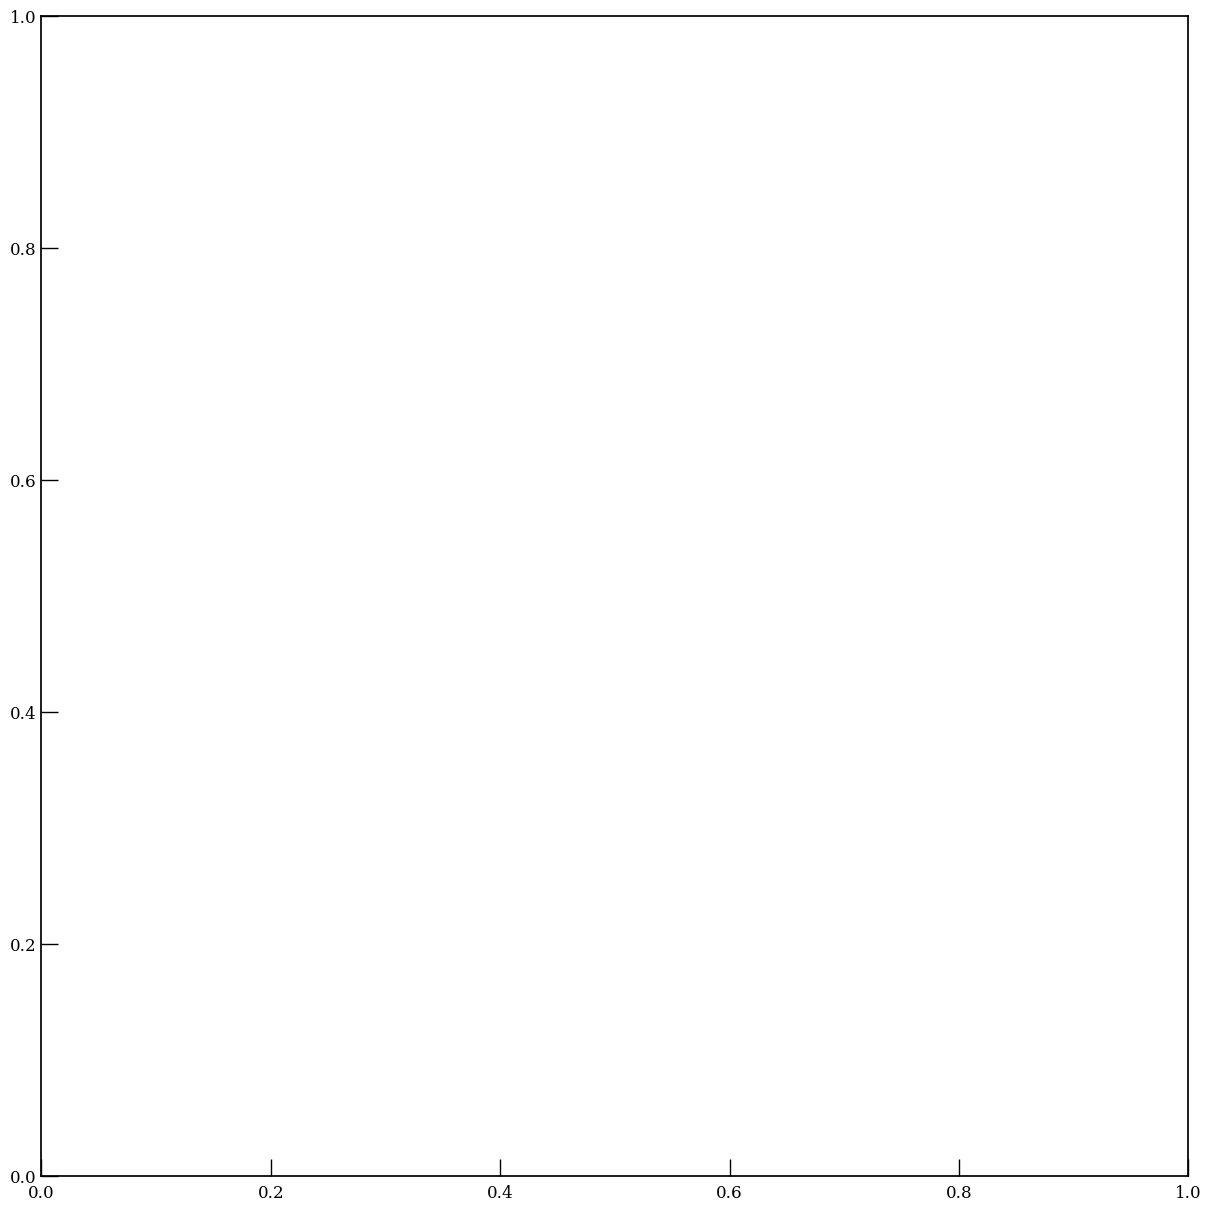

In [8]:
from scipy import stats
fig, ax = plt.subplots(figsize=(12,12))
xlow = 25; xhigh = 140
xline = np.linspace(xlow, xhigh,1000)
cmap = plt.get_cmap('Set2')
color_ind = 0
fontsize=16

xshift = 1
for key, val in combinedDict.items():
    print(key)
    cutTable = bgs_matched[val]
    numTotal = len(cutTable)
    numCluster = len(np.unique(cutTable['ID']))

    lambda_true_list = []
    lambda_rm_list = []
    lambda_rm_stddev_list = []
    lambda_true_stddev_list = []
    lambda_rm_sem_list = []
    lambda_true_sem_list = []
    for i, lmda_bin in enumerate(lmda_bins):
        cut = (cutTable['LAMBDA'] >= lmda_bin[0]) & (cutTable['LAMBDA'] < lmda_bin[1])
            
        binnedTable = cutTable[cut]
        lambda_tot, lambda_true, lambda_true_err_std, lambda_true_err = calc_specRichness_stacked(binBoundaries, binCent, binnedTable)

        numCl = len(unique(binnedTable, keys='ID'))
        lambda_rm_list = np.hstack((lambda_rm_list, np.mean(binnedTable['LAMBDA'])))  
        lambda_rm_stddev_list = np.hstack((lambda_rm_stddev_list, np.std(binnedTable['LAMBDA']))) 
        lambda_rm_sem_list = np.hstack((lambda_rm_sem_list, stats.sem(binnedTable['LAMBDA'])))  
        lambda_true_stddev_list = np.hstack((lambda_true_stddev_list, lambda_true_err))
        lambda_true_sem_list = np.hstack((lambda_true_sem_list, lambda_true_err/np.sqrt(numCl)))
        lambda_true_list = np.hstack((lambda_true_list,lambda_true))   

    ##Linear fitting
    bcesMethod=0
    ##Use the standard error for errors on the coefficients. 
    slope, intercept, slope_err, intercept_err, covab = linear_fit(lambda_rm_list, lambda_true_list, lambda_rm_sem_list, lambda_true_sem_list, bcesMethod=bcesMethod)

    ##Use the standard error of the regression (approx. standard deviation) for goodness of fit.
    chi_squared, degrees_of_freedom, p_value = compute_chisq(lambda_rm_list, lambda_true_list, lambda_rm_stddev_list, lambda_true_stddev_list, slope, intercept, \
                                                             cov=False, verbose=True)
    best_fit_label = r'$\log(y)={:.2f}(\pm {:.2f})\log(x) {:+.2f}(\pm {:.2f}), p={:.3f}$'.format(slope, slope_err, intercept, intercept_err, p_value)
    label = key + ', ' + r'$N={:d}$'.format(numCluster) + r', $n={:d}$'.format(numTotal) + ', ' + best_fit_label

    ##Set pivot point to 60
    bias = np.log10(60)*(1-slope)-intercept
    intercept += bias
    y_fitted = 10**intercept * xline**slope
    ax.plot(xline, y_fitted, linestyle='-.', color=cmap(color_ind))
    best_fit_label = r'$\log(y)={:.2f}(\pm {:.2f})\log(x) {:+.2f}(\pm {:.2f}), p={:.3f}$'.format(slope, slope_err, intercept, intercept_err, p_value)
    label = key + ', ' + r'$N={:d}$'.format(numCluster) + r', $n={:d},$'.format(numTotal) ## + '\n ' + best_fit_label + '\n'

    print(best_fit_label)
    ##After setting the pivot point both the values and the errors in linear scale are multiplied by a factor of 10**bias. 
    ax.errorbar(lambda_rm_list*xshift, lambda_true_list*10**bias, xerr = lambda_rm_stddev_list, yerr = lambda_true_stddev_list*10**bias, \
                linestyle='none', label=label, capsize=12, ms=7, color=cmap(color_ind), fmt='o')

    #covm=np.array([ (slope_err[bcesMethod]**2,covab[bcesMethod]), (covab[bcesMethod], intercept_err[bcesMethod]**2) ])	
    # Gets lower and upper bounds on the confidence band 
    #lcb,ucb,xcb=nmmn.stats.confbandnl(xline,y_fitted,func,fitm,covm,2,0.954,x)
    #print((lambda_true_list*10**bias-y_fitted)/lambda_true_stddev_list)

    xshift *= 1.02
    color_ind +=1

ax.plot(xline,xline,color='black', linestyle='dashed')   
ax.set_xlabel(r'$\lambda_{\rm RM}$', fontsize=fontsize)
ax.set_ylabel(r'$\lambda_{\rm Spec}$', fontsize=fontsize)

ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([20,30,50,70,100,150])
ax.set_yticks([5,10,20,30,50,100,300])
ax.set_xscale('log'); 
ax.set_yscale('log')
ax.set_xlim([xlow, xhigh]); 
ax.set_ylim([xlow, xhigh])
plt.legend(frameon=False, loc='best', fontsize=fontsize)
#plt.savefig('plots/lambda_spec_lambda_rm_binned_lmda_gtr20_bivariate_error.jpeg')
plt.show()

### Plotting the confidence bands

Suppose you want to include in the plot a visual estimate of the uncertainty on the fit. This is called the confidence band. For example, the $3\sigma$ confidence interval is 99.7% sure to contain the best-fit regression line. Note that this is *not* the same as saying it will contain 99.7% of the data points. For more information, [check this out](http://www.jerrydallal.com/LHSP/slr.htm).

In order to plot the confidence band, you will need to [install the `nmmn` package](https://github.com/rsnemmen/nmmn#installation) and another dependency: 

    pip install nmmn numdifftools

After installing the package, follow the instructions below to plot the confidence band of your fit.

First we define convenient arrays that encapsulate the fit parameters and their uncertainties—including the covariance.

In [11]:
# convenient function for a line
def func(x): return x[1]*x[0]+x[2]

In [17]:
##Change the binning of lambda

## Bin by redshift
z_bins = [[0.1,0.2],[0.2,0.3],[0.3,0.4]]

lmda_bin_edges = np.logspace(np.log10(30), np.log10(120), 10)
lmda_bins = [[lmda_bin_edges[i], lmda_bin_edges[i+1]] for i in range(len(lmda_bin_edges)-1)]

##Create an absolute magnitude column
cosmo = Planck18
h = 0.67
M_r = bgs_matched['r_dered']-cosmo.distmod(bgs_matched['Z_BGS']).value - 5*np.log10(h)
bgs_matched['M_r'] = M_r ##comoving M with h-scaling

##Cuts
bgs_matched = bgs_matched[np.where(bgs_matched['r_dered'] < 19.5)]

/global/homes/z/zzhang13/.conda/envs/myEnv_v39/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/global/homes/z/zzhang13/.conda/envs/myEnv_v39/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/global/homes/z/zzhang13/.conda/envs/myEnv_v39/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/global/homes/z/zzhang13/.conda/envs/myEnv_v39/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


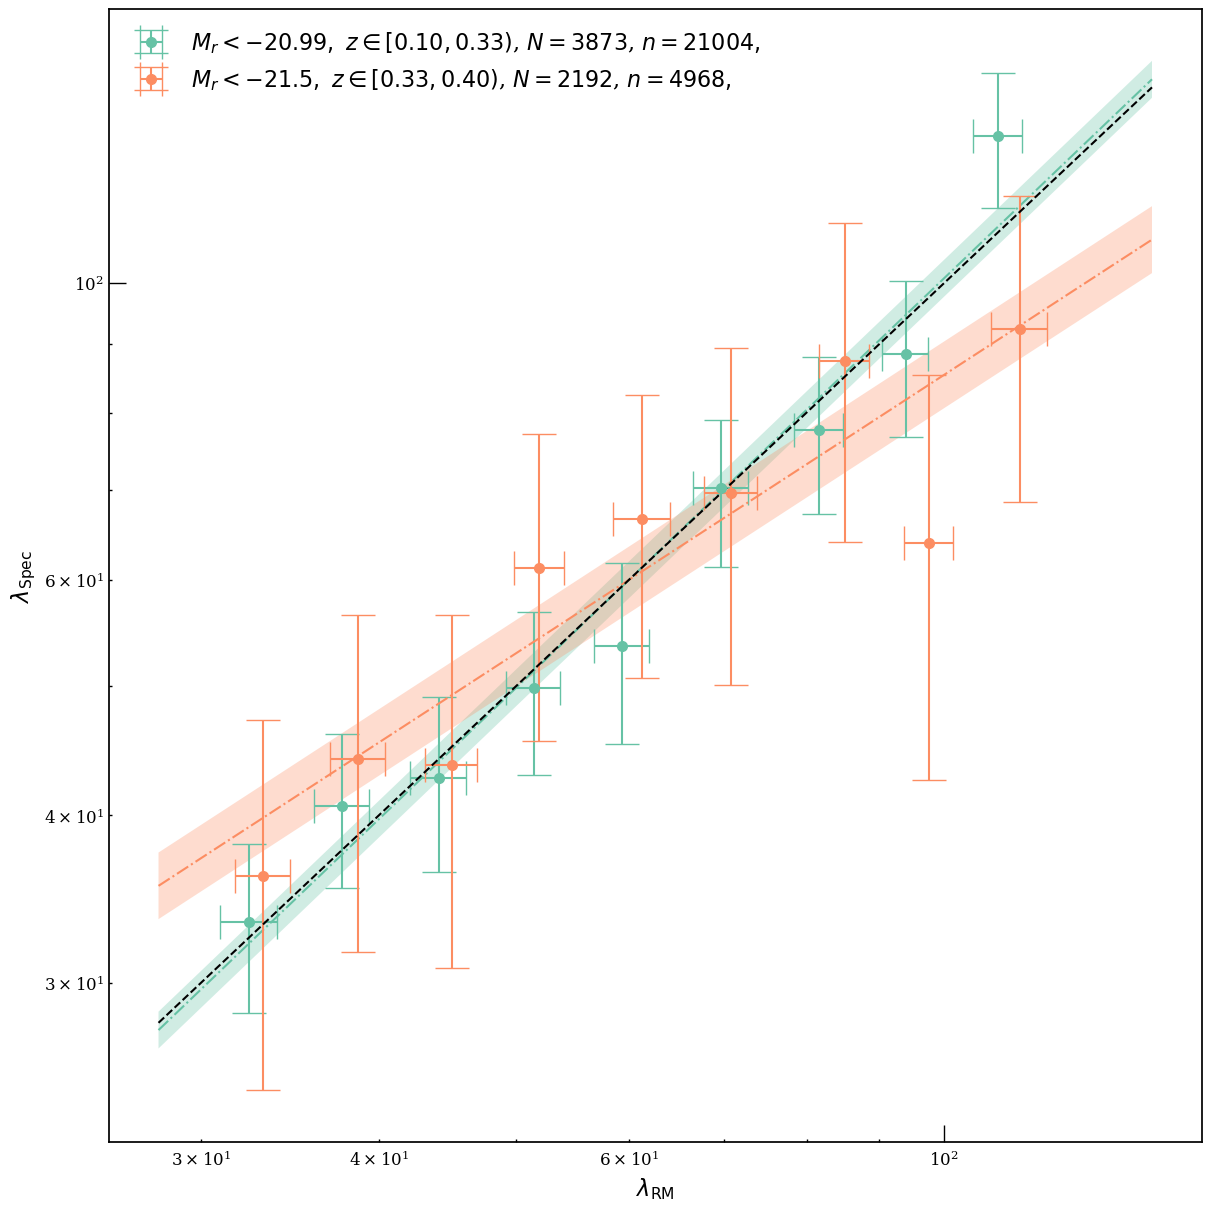

In [18]:
from scipy import stats
import nmmn.stats
fig, ax = plt.subplots(figsize=(12,12))
xlow = 28; xhigh = 140
xline = np.linspace(xlow, xhigh,1000)
cmap = plt.get_cmap('Set2')
color_ind = 0
fontsize=16

xshift = 1
for key, val in combinedDict.items():
    #print(key)
    cutTable = bgs_matched[val]
    numTotal = len(cutTable)
    numCluster = len(np.unique(cutTable['ID']))

    lambda_true_list = []
    lambda_rm_list = []
    lambda_rm_stddev_list = []
    lambda_true_stddev_list = []
    lambda_rm_sem_list = []
    lambda_true_sem_list = []
    for i, lmda_bin in enumerate(lmda_bins):
        cut = (cutTable['LAMBDA'] >= lmda_bin[0]) & (cutTable['LAMBDA'] < lmda_bin[1])
            
        binnedTable = cutTable[cut]
        lambda_tot, lambda_true, lambda_true_err = calc_specRichness_stacked(binBoundaries, binCent, binnedTable)

        numCl = len(unique(binnedTable, keys='ID'))
        lambda_rm_list = np.hstack((lambda_rm_list, np.mean(binnedTable['LAMBDA'])))  
        lambda_rm_stddev_list = np.hstack((lambda_rm_stddev_list, np.std(binnedTable['LAMBDA']))) 
        lambda_rm_sem_list = np.hstack((lambda_rm_sem_list, stats.sem(binnedTable['LAMBDA'])))  
        lambda_true_stddev_list = np.hstack((lambda_true_stddev_list, lambda_true_err))
        lambda_true_sem_list = np.hstack((lambda_true_sem_list, lambda_true_err/np.sqrt(numCl)))
        lambda_true_list = np.hstack((lambda_true_list,lambda_true))   

    ##Linear fitting
    bcesMethod=0
    ##Use the standard error for errors on the coefficients. 
    slope, intercept, slope_err, intercept_err, covab = linear_fit(lambda_rm_list, lambda_true_list, lambda_rm_sem_list, lambda_true_sem_list, bcesMethod=bcesMethod)

    ##Use the standard error of the regression (approx. standard deviation) for goodness of fit.
    chi_squared, degrees_of_freedom, p_value = compute_chisq(lambda_rm_list, lambda_true_list, lambda_rm_stddev_list, lambda_true_stddev_list, slope, intercept, \
                                                             cov=False, verbose=False)
    best_fit_label = r'$\log(y)={:.2f}(\pm {:.2f})\log(x) {:+.2f}(\pm {:.2f}), p={:.3f}$'.format(slope, slope_err, intercept, intercept_err, p_value)
    label = key + ', ' + r'$N={:d}$'.format(numCluster) + r', $n={:d}$'.format(numTotal) + ', ' + best_fit_label


    ##Plotting the confidence bands
    fitm=np.array([ slope, intercept])	
    covm=np.array([ (slope_err**2,covab), (covab, intercept_err) ])	
    #Gets lower and upper bounds on the confidence band 
    lcb,ucb,xcb=nmmn.stats.confbandnl(np.log10(lambda_rm_list), np.log10(lambda_true_list), func, fitm, covm, 2, 0.68, x=np.log10(xline)) ##2-sigma confidence bands
    

    ##Set pivot point to 60
    bias = np.log10(60)*(1-slope)-intercept
    intercept += bias
    y_fitted = 10**intercept * xline**slope
    y_data = lambda_true_list*10**bias
    x_data = lambda_rm_list*xshift
    x_err = lambda_rm_stddev_list
    y_err = lambda_true_stddev_list*10**bias
    
    ax.plot(xline, y_fitted, linestyle='-.', color=cmap(color_ind))
    best_fit_label = r'$\log(y)={:.2f}(\pm {:.2f})\log(x) {:+.2f}(\pm {:.2f}), p={:.3f}$'.format(slope, slope_err, intercept, intercept_err, p_value)
    label = key + ', ' + r'$N={:d}$'.format(numCluster) + r', $n={:d},$'.format(numTotal) ## + '\n ' + best_fit_label + '\n'

    #print(best_fit_label)
    ##After setting the pivot point both the values and the errors in linear scale are multiplied by a factor of 10**bias. 
    ax.errorbar(x_data, y_data, xerr = x_err, yerr = y_err, \
                linestyle='none', label=label, capsize=12, ms=7, color=cmap(color_ind), fmt='o')

    ##To include the bias when plotting confidence bands
    ax.fill_between(xline, 10**(lcb+bias), 10**(ucb+bias), alpha=0.3, facecolor=cmap(color_ind))
    
    xshift *= 1.02
    color_ind +=1

ax.plot(xline,xline,color='black', linestyle='dashed')   
ax.set_xlabel(r'$\lambda_{\rm RM}$', fontsize=fontsize)
ax.set_ylabel(r'$\lambda_{\rm Spec}$', fontsize=fontsize)

ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([20,30,50,70,100,150])
ax.set_yticks([5,10,20,30,50,100,300])
ax.set_xscale('log'); 
ax.set_yscale('log')
#ax.set_xlim([xlow, xhigh]); 
#ax.set_ylim([xlow, xhigh])
plt.legend(frameon=False, loc='best', fontsize=fontsize)
#plt.savefig('plots/lambda_spec_lambda_rm_binned_lmda_gtr30_confidence_1sigma.jpeg')
plt.show()

## Including the other richness mass relations
Let's first use the reported scatter as the confidence bands even though that's not a good method. 

* Bocquet
* Giles
* Matteo
* To

In [126]:
log10lambda = np.linspace(np.log10(20),np.log10(200),100)

### Chains for Tomomi


In [127]:
directory = 'chains/richness-mass/'
file = 'chain-real-hscs19a-fid-dpz0.093-corrected-tol0.01-final.txt'

In [128]:
import numpy as np

N_PARAMS = 22 
# Replace 'path/to/your/output/_post_equal_weights.dat' with the actual path
data = np.loadtxt(directory+file)

# The first N_PARAMS columns are the parameters, followed by logL and logP
parameters = data[:, :N_PARAMS]
log_prior = data[:, N_PARAMS]
log_likelihood = data[:, N_PARAMS + 1]

mpiv = 3*10**14

In [129]:
a = data[:,5];
b = data[:,6]
sig0 = data[:,7]
q = data[:,8]

flatchain = np.asarray([a,b,sig0,q]).T

In [130]:
a, b, sig0, q = map(lambda v: (v[1], v[2]-v[1], v[1]-v[0]),
                             zip(*np.percentile(flatchain, [16, 50, 84], axis=0)))
print('a: best fit, upper_err, lower_err', a)
print('b: best fit, upper_err, lower_err', b)
print('sig0: best fit, upper_err, lower_err', sig0)
print('q: best fit, upper_err, lower_err', q)

a_best = a[0]
b_best = b[0]
sig0_best = sig0[0]
q_best = q[0]

a: best fit, upper_err, lower_err (3.3818738573364326, 0.2698796258403111, 0.6111570113472053)
b: best fit, upper_err, lower_err (0.9591401901767675, 0.11748144082733192, 0.18911199599779127)
sig0: best fit, upper_err, lower_err (0.3607176035118247, 0.35912815963245637, 0.10869444837987396)
q: best fit, upper_err, lower_err (-0.11846804961096635, 0.21445431926617642, 0.07446249533458549)


In [149]:
b_best = b[0]
slope_S24 = 1/(b_best)
logM_S24 = slope_S24*log10lambda 

#Adjust the lambda pivot point to 60. bias = log(60)*(1-slope)-intercept
bias_S24 = np.log10(60)*(1-slope_S24)
logM_S24 += bias_S24
M_S24 = 10**logM_S24

##Poisson scatter
sigma_log10l = sig0_best/np.log(10)
sigma_log10M = sigma_log10l*slope_B24
sigma_M_S24 = np.sqrt(M_S24**2 * (10**(sigma_log10M**2)-1)) 

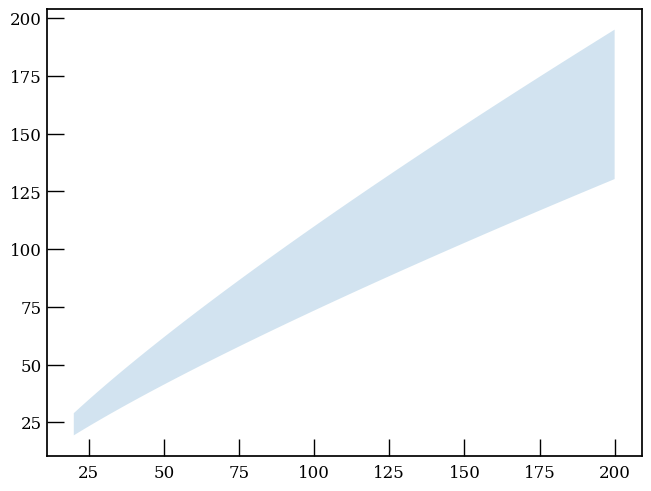

In [150]:
plt.fill_between(10**log10lambda, M_S24-sigma_M_S24, M_S24+sigma_M_S24, alpha=0.2, label = 'Sunayama+24')
plt.show()

### Bocquet 

In [132]:
directory = 'chains/richness-mass/'
file = 'MCMF500dnf_HST_count_Csz_WISE_SZlensingrichness_CAMB_full_v0.txt'

In [133]:
N_PARAMS = 30
# Replace 'path/to/your/output/_post_equal_weights.dat' with the actual path
data = np.loadtxt(directory+file)

# The first N_PARAMS columns are the parameters, followed by logL and logP
parameters = data[:, :N_PARAMS]
log_prior = data[:, N_PARAMS]
log_likelihood = data[:, N_PARAMS + 1]

In [134]:
a = data[:,12];
b = data[:,13]
sigma_lnl = data[:,15]
flatchain = np.asarray([a,b, sigma_lnl]).T

a, b, sigma_lnl = map(lambda v: (v[1], v[2]-v[1], v[1]-v[0]),
                             zip(*np.percentile(flatchain, [16, 50, 84], axis=0)))
print('b: best fit, upper_err, lower_err', b)
print('sigma_lnl: best fit, upper_err, lower_err', sigma_lnl)

b_best = b[0]
sigma_lnl_best = sigma_lnl[0]
slope_B24 = 1/(b_best)
logM_B24 = slope_B24*log10lambda 

#Adjust the lambda pivot point to 60. bias = log(60)*(1-slope)-intercept
bias_B24 = np.log10(60)*(1-slope)
logM_B24 += bias_S24
M_B24 = 10**logM_S24

##Poisson scatter
sigma_log10l = sigma_lnl_best/np.log(10)
sigma_log10M = sigma_log10l*slope_B24
sigma_M_B24 = np.sqrt(M_B24**2 * (10**(sigma_log10M**2)-1)) 


print(bias_B24)
print(sigma_M_B24)

b: best fit, upper_err, lower_err (1.2069152509848151, 0.09155175998566745, 0.10932214383145222)
sigma_lnl: best fit, upper_err, lower_err (0.19735977119932654, 0.08591572547886103, 0.05183528128325546)
-0.07575005475917819
[ 2.06272115  2.113352    2.16522562  2.21837251  2.27282393  2.32861189
  2.3857692   2.44432948  2.50432716  2.56579752  2.62877672  2.69330177
  2.75941064  2.8271422   2.89653627  2.96763366  3.04047618  3.11510668
  3.19156902  3.26990819  3.35017024  3.43240238  3.51665296  3.60297153
  3.69140884  3.7820169   3.874849    3.96995973  4.06740501  4.16724214
  4.26952985  4.37432828  4.48169905  4.59170531  4.70441174  4.81988463
  4.93819188  5.05940305  5.18358944  5.31082406  5.44118174  5.57473913
  5.71157478  5.85176915  5.99540468  6.14256584  6.29333917  6.44781333
  6.60607916  6.76822973  6.93436039  7.10456884  7.27895517  7.45762192
  7.64067417  7.82821956  8.02036837  8.2172336   8.41893102  8.62557923
  8.83729976  9.05421711  9.27645884  9.504155

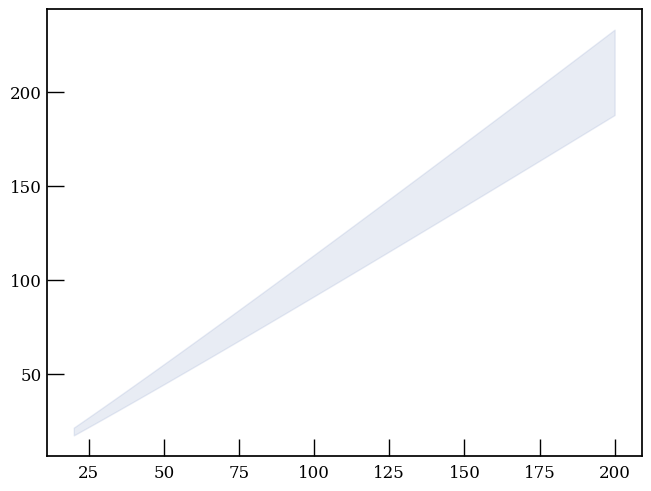

In [135]:
##This shows the standard deviation not the confidence interval. To do that you need the slope, intercept and covariance. 
plt.fill_between(10**log10lambda, M_B24-sigma_M_B24, M_B24+sigma_M_B24, alpha=0.2, label = 'Bocquet+24', color=cmap(color_ind))
plt.show()

## Temperature and Luminosity from Paul Giles

https://arxiv.org/pdf/2202.11107

In [136]:
a = data[:,12];
b = data[:,13]
sigma_lnl = data[:,15]
flatchain = np.asarray([a,b, sigma_lnl]).T

a, b, sigma_lnl = map(lambda v: (v[1], v[2]-v[1], v[1]-v[0]),
                             zip(*np.percentile(flatchain, [16, 50, 84], axis=0)))
print('b: best fit, upper_err, lower_err', b)
print('sigma_lnl: best fit, upper_err, lower_err', sigma_lnl)

b_Tx_best = 0.59
b_Lx_best = 1.61
sigma_lnl_Tx_best = 0.33
sigma_lnl_Lx_best = 1.07
slope_Tx_G22 = b_Tx_best #Note this is not inverse as the scaling relations are not inverted
slope_Lx_G22 = b_Lx_best

logM_Tx_G22 = slope_Tx_G22*log10lambda
logM_Lx_G22 = slope_Lx_G22*log10lambda 

#Adjust the lambda pivot point to 60. bias = log(60)*(1-slope)-intercept
bias_Tx_G22 = np.log10(60)*(1-slope_Tx_G22)
bias_Lx_G22 = np.log10(60)*(1-slope_Lx_G22)

logM_Tx_G22 += bias_Tx_G22
logM_Lx_G22 += bias_Lx_G22
M_Tx_G22 = 10**logM_Tx_G22
M_Lx_G22 = 10**logM_Lx_G22

##Scatter
sigma_Tx_log10l = sigma_lnl_Tx_best/np.log(10)
sigma_Tx_log10M = sigma_Tx_log10l*slope_Tx_G22
sigma_M_Tx_G22 = np.sqrt(M_Tx_G22**2 * (10**(sigma_Tx_log10M**2)-1)) 

sigma_Lx_log10l = sigma_lnl_Lx_best/np.log(10)
sigma_Lx_log10M = sigma_Lx_log10l*slope_Lx_G22
sigma_M_Lx_G22 = np.sqrt(M_Lx_G22**2 * (10**(sigma_Lx_log10M**2)-1)) 

b: best fit, upper_err, lower_err (1.2069152509848151, 0.09155175998566745, 0.10932214383145222)
sigma_lnl: best fit, upper_err, lower_err (0.19735977119932654, 0.08591572547886103, 0.05183528128325546)


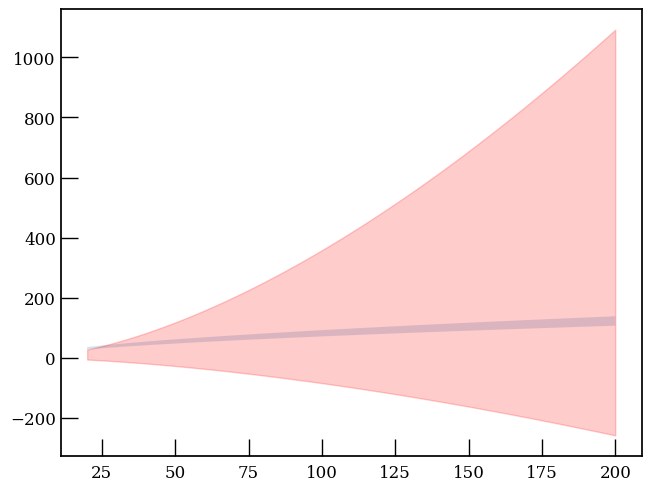

In [137]:
##This shows the standard deviation not the confidence interval. To do that you need the slope, intercept and covariance. 
plt.fill_between(10**log10lambda, M_Tx_G22-sigma_M_Tx_G22, M_Tx_G22+sigma_M_Tx_G22, alpha=0.2)
plt.fill_between(10**log10lambda, M_Lx_G22-sigma_M_Lx_G22, M_Lx_G22+sigma_M_Lx_G22, alpha=0.2, color='red')
plt.show()

### Chunhao To

https://arxiv.org/pdf/2010.01138

In [138]:
a_best = 0.943
sigma_lnl_best = 0.299
slope_T21 = 1/(a_best)
logM_T21 = slope_T21*log10lambda 

#Adjust the lambda pivot point to 60. bias = log(60)*(1-slope)-intercept
bias_T21 = np.log10(60)*(1-slope)
logM_T21 += bias_S24
M_T21 = 10**logM_S24

##Poisson scatter
sigma_log10l = sigma_lnl_best/np.log(10)
sigma_log10M = sigma_log10l*slope_B24
sigma_M_T21 = np.sqrt(M_T21**2 * (10**(sigma_log10M**2)-1)) 